In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('delhiaqi.csv')
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB


In [3]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


In [4]:
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour,day
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83,0,1
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66,1,1
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40,2,1
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55,3,1
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19,4,1


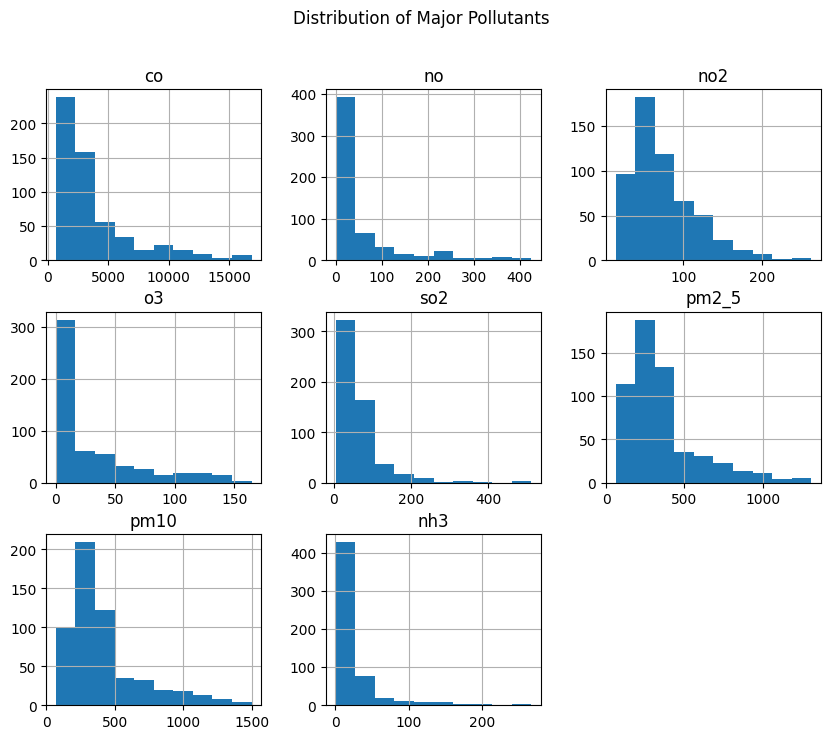

In [5]:
df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].hist(figsize=(10,8))
plt.suptitle("Distribution of Major Pollutants")
plt.show()

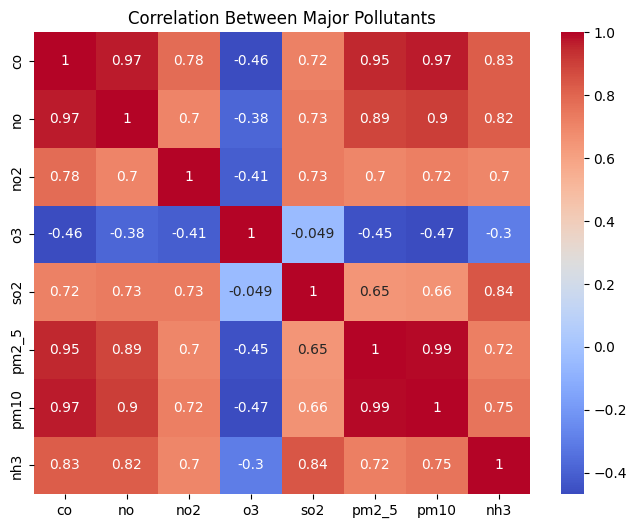

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Major Pollutants")
plt.show()

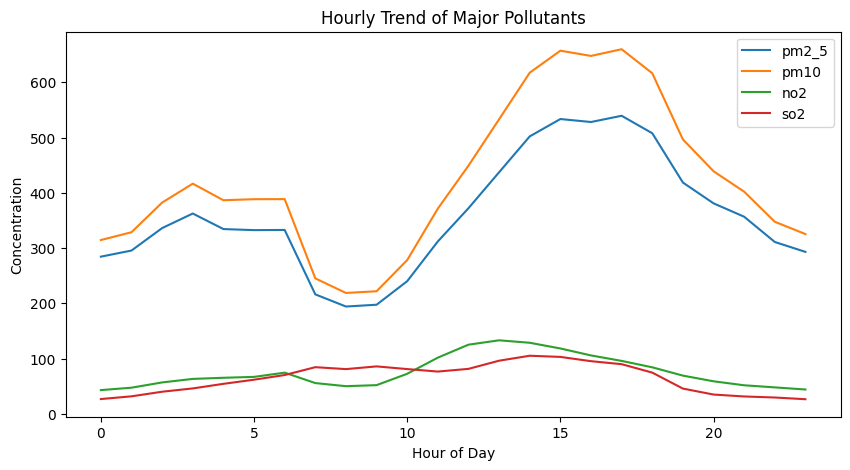

In [7]:
hourly = df.groupby('hour')[['pm2_5','pm10','no2','so2']].mean()

hourly.plot(figsize=(10,5))
plt.title("Hourly Trend of Major Pollutants")
plt.xlabel("Hour of Day")
plt.ylabel("Concentration")
plt.show()

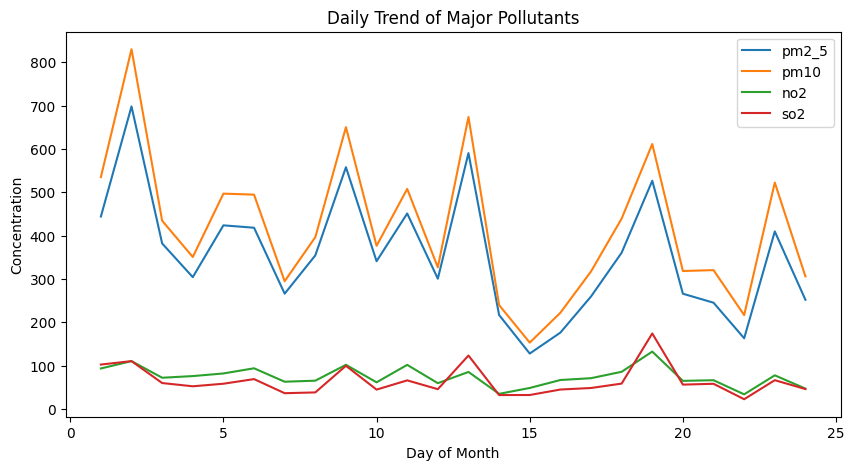

In [8]:
daily = df.groupby('day')[['pm2_5','pm10','no2','so2']].mean()

daily.plot(figsize=(10,5))
plt.title("Daily Trend of Major Pollutants")
plt.xlabel("Day of Month")
plt.ylabel("Concentration")
plt.show()

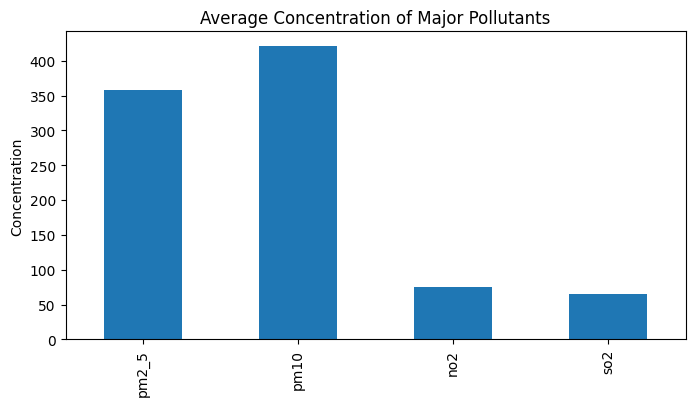

In [9]:
df[['pm2_5','pm10','no2','so2']].mean().plot(kind='bar', figsize=(8,4))
plt.title("Average Concentration of Major Pollutants")
plt.ylabel("Concentration")
plt.show()

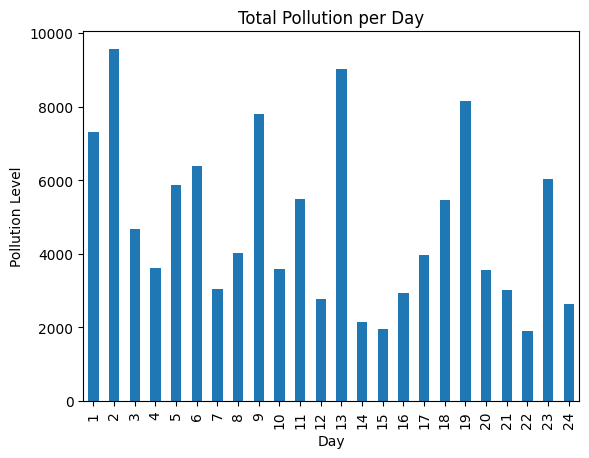

In [10]:
df['total_pollution'] = df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].sum(axis=1)

daily_total = df.groupby('day')['total_pollution'].mean()

daily_total.plot(kind='bar')

plt.title("Total Pollution per Day")
plt.xlabel("Day")
plt.ylabel("Pollution Level")
plt.show()